# Trial Analysis

Optimization convergence, fitness distributions, pruning behavior, and
throughput for a single experiment run.

Set `EXPERIMENT_DIR` via env var (nbconvert) or edit the loader cell.

In [1]:
import json
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from optuna.trial import TrialState

# EXPERIMENT_DIR may be overridden via env var (used by nbconvert for batch execution).
EXPERIMENT_DIR = Path(os.environ.get(
    "EXPERIMENT_DIR",
    "../experiments/hammerhead-twfe-2026-04-13",
)).resolve()

db_files = sorted(EXPERIMENT_DIR.glob("*.db"))
if not db_files:
    raise FileNotFoundError(f"No .db file in {EXPERIMENT_DIR}")
# Prefer a name matching the directory (e.g. hammerhead.db over hammerhead_snapshot_0837.db).
preferred = [p for p in db_files if "_" not in p.stem]
STUDY_DB = preferred[0] if preferred else db_files[0]

log_files = sorted(EXPERIMENT_DIR.glob("evaluation_log*.jsonl"))
if not log_files:
    raise FileNotFoundError(f"No evaluation_log*.jsonl in {EXPERIMENT_DIR}")
preferred_log = [p for p in log_files if p.name == "evaluation_log.jsonl"]
EVAL_LOG = preferred_log[0] if preferred_log else log_files[0]

storage = f"sqlite:///{STUDY_DB}"
study_names = optuna.get_all_study_names(storage)
if len(study_names) != 1:
    raise RuntimeError(f"Expected 1 study in {STUDY_DB}, found {study_names}")
STUDY_NAME = study_names[0]

study = optuna.load_study(study_name=STUDY_NAME, storage=storage)
trials = study.trials

eval_entries = []
with open(EVAL_LOG) as f:
    for line in f:
        eval_entries.append(json.loads(line))

print(f"Experiment: {EXPERIMENT_DIR.name}")
print(f"Study: {STUDY_NAME}  ({STUDY_DB.name})")
print(f"Eval log: {EVAL_LOG.name}  ({len(eval_entries)} entries)")
print(f"Trials in study: {len(trials)}")
state_counts = pd.Series([t.state.name for t in trials]).value_counts().to_dict()
print(f"States: {state_counts}")

/home/sdai/ClaudeCode/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment: hammerhead-twfe-2026-04-13
Study: hammerhead  (hammerhead.db)
Eval log: evaluation_log.jsonl  (368 entries)
Trials in study: 888
States: {'COMPLETE': 829, 'PRUNED': 55, 'RUNNING': 4}


## Fitness Distribution

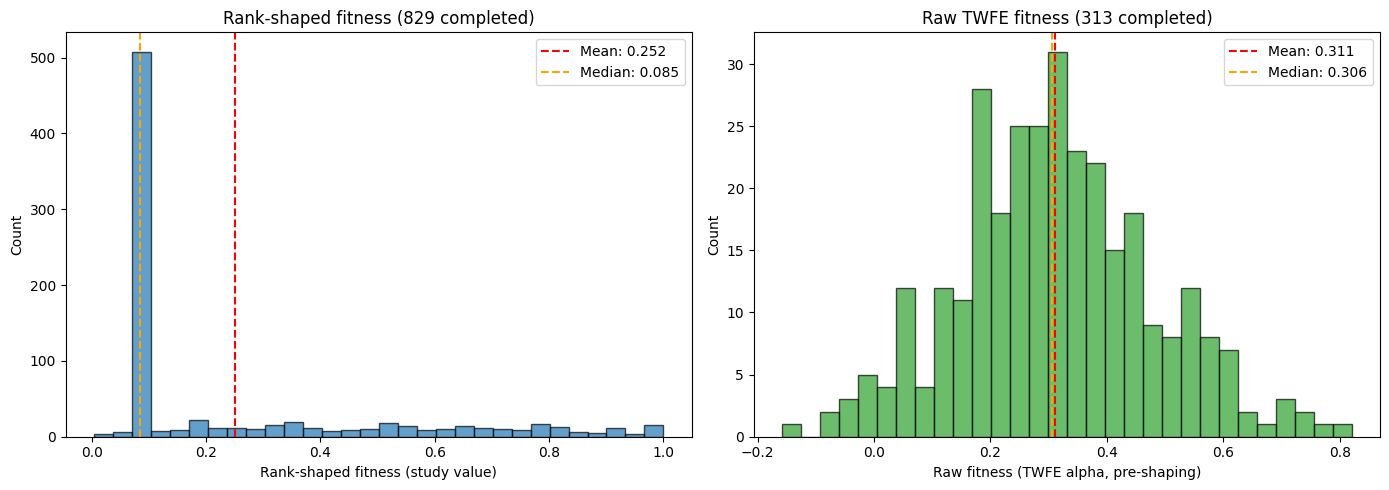

Completed: 829  Pruned: 55  Running: 4
Rank-shaped — min=0.004  max=1.000  mean=0.252  std=0.266
Raw TWFE    — min=-0.158  max=0.820  mean=0.311  std=0.168


In [2]:
completed = [t for t in trials if t.state == TrialState.COMPLETE]
pruned = [t for t in trials if t.state == TrialState.PRUNED]
running = [t for t in trials if t.state == TrialState.RUNNING]

# Completed trial values are the optimizer objective (rank-shaped).
fitness_values = [t.value for t in completed if t.value is not None]

# Raw TWFE alpha from eval log (before rank shaping), for completed-only.
completed_entries = [e for e in eval_entries if not e["pruned"]]
raw_values = [e["raw_fitness"] for e in completed_entries if e["raw_fitness"] is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fitness_values, bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(np.mean(fitness_values), color="red", linestyle="--",
                label=f"Mean: {np.mean(fitness_values):.3f}")
axes[0].axvline(np.median(fitness_values), color="orange", linestyle="--",
                label=f"Median: {np.median(fitness_values):.3f}")
axes[0].set_xlabel("Rank-shaped fitness (study value)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Rank-shaped fitness ({len(completed)} completed)")
axes[0].legend()

if raw_values:
    axes[1].hist(raw_values, bins=30, edgecolor="black", alpha=0.7, color="tab:green")
    axes[1].axvline(np.mean(raw_values), color="red", linestyle="--",
                    label=f"Mean: {np.mean(raw_values):.3f}")
    axes[1].axvline(np.median(raw_values), color="orange", linestyle="--",
                    label=f"Median: {np.median(raw_values):.3f}")
    axes[1].set_xlabel("Raw fitness (TWFE alpha, pre-shaping)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Raw TWFE fitness ({len(raw_values)} completed)")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "raw_fitness missing from log", ha="center", va="center",
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print(f"Completed: {len(completed)}  Pruned: {len(pruned)}  Running: {len(running)}")
print(f"Rank-shaped — min={min(fitness_values):.3f}  max={max(fitness_values):.3f}  "
      f"mean={np.mean(fitness_values):.3f}  std={np.std(fitness_values):.3f}")
if raw_values:
    print(f"Raw TWFE    — min={min(raw_values):.3f}  max={max(raw_values):.3f}  "
          f"mean={np.mean(raw_values):.3f}  std={np.std(raw_values):.3f}")

## Optimization Convergence

Best fitness over trial number with rolling mean/IQR window.

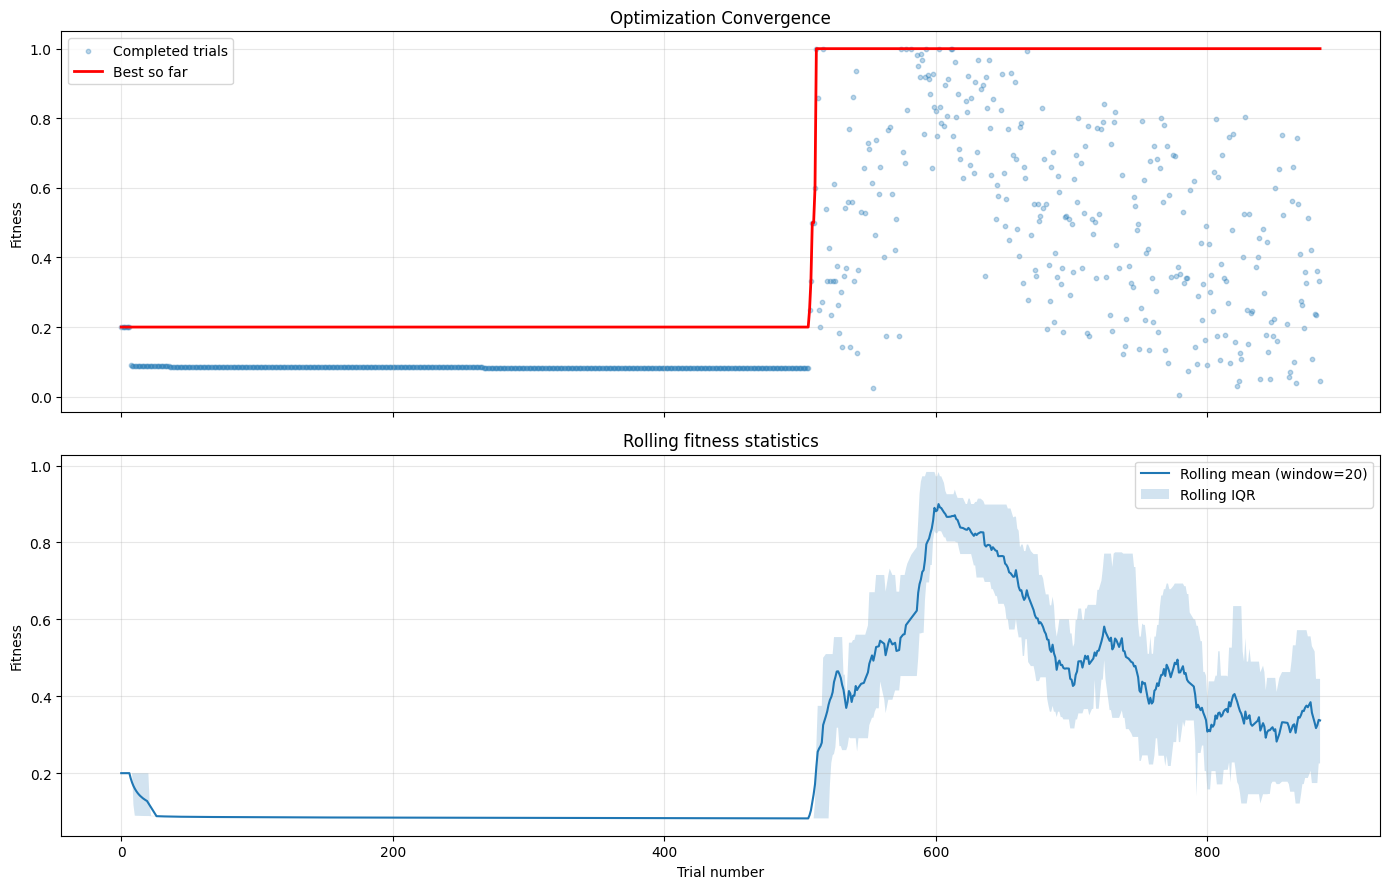

Best trial: #512  fitness=1.0000
First trial reaching top-10% (0.720): completed index 512 (trial #512)


In [3]:
completed_sorted = sorted(completed, key=lambda t: t.number)
trial_nums = [t.number for t in completed_sorted]
values = [t.value for t in completed_sorted]

running_best = np.maximum.accumulate(values)

window = max(10, len(values) // 40)
s = pd.Series(values)
rolling_mean = s.rolling(window, min_periods=1).mean()
rolling_q25 = s.rolling(window, min_periods=1).quantile(0.25)
rolling_q75 = s.rolling(window, min_periods=1).quantile(0.75)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].scatter(trial_nums, values, alpha=0.3, s=10, label="Completed trials")
axes[0].plot(trial_nums, running_best, color="red", linewidth=2, label="Best so far")
axes[0].set_ylabel("Fitness")
axes[0].set_title("Optimization Convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(trial_nums, rolling_mean, color="tab:blue", linewidth=1.5,
             label=f"Rolling mean (window={window})")
axes[1].fill_between(trial_nums, rolling_q25, rolling_q75, alpha=0.2,
                     label="Rolling IQR")
axes[1].set_xlabel("Trial number")
axes[1].set_ylabel("Fitness")
axes[1].set_title("Rolling fitness statistics")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_trial = max(completed, key=lambda t: t.value)
print(f"Best trial: #{best_trial.number}  fitness={best_trial.value:.4f}")
top_thresh = np.percentile(values, 90)
first_top = next((i for i, v in enumerate(values) if v >= top_thresh), None)
if first_top is not None:
    print(f"First trial reaching top-10% ({top_thresh:.3f}): completed index {first_top} "
          f"(trial #{trial_nums[first_top]})")

## Pruning Analysis

Rung distribution of pruned trials and outcome mix across all trials.
Rungs correspond to number of opponents evaluated before the pruner decided.

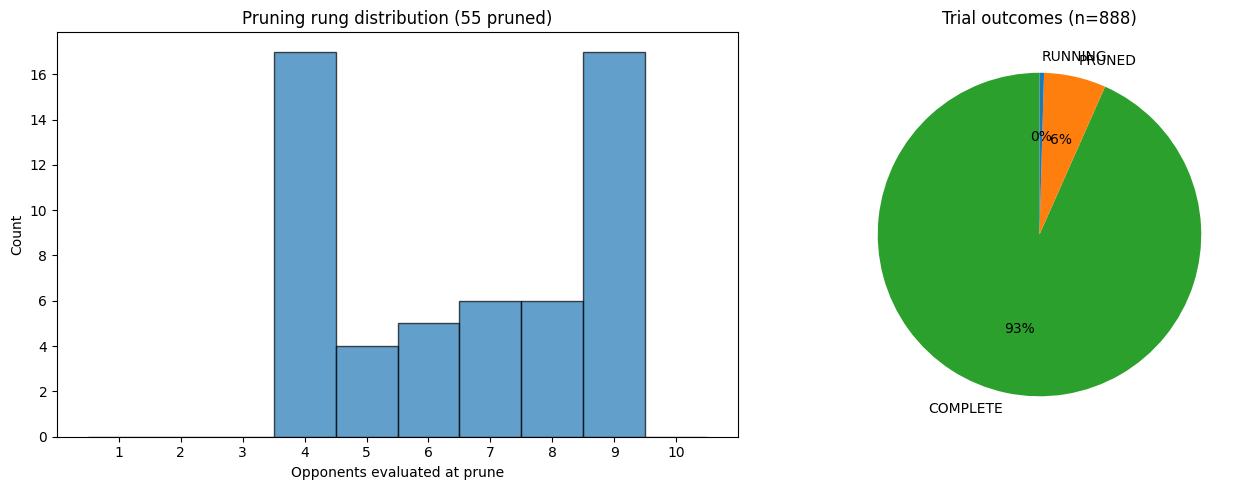

Pruned in eval log: 55/368 (15%)
Mean prune rung: 6.6  median: 7.0
Opponent matchups saved by pruning: 189 (~5.1% of total eval budget)


In [4]:
pruned_entries = [e for e in eval_entries if e["pruned"]]
completed_entries = [e for e in eval_entries if not e["pruned"]]

pruned_rungs = [e["opponents_evaluated"] for e in pruned_entries]
total_rung = eval_entries[0]["opponents_total"] if eval_entries else 10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if pruned_rungs:
    bins = range(1, total_rung + 2)
    axes[0].hist(pruned_rungs, bins=bins, edgecolor="black", alpha=0.7, align="left")
    axes[0].set_xlabel("Opponents evaluated at prune")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Pruning rung distribution ({len(pruned_entries)} pruned)")
    axes[0].set_xticks(range(1, total_rung + 1))
else:
    axes[0].text(0.5, 0.5, "No pruned trials", ha="center", va="center",
                 transform=axes[0].transAxes)

state_counts = pd.Series([t.state.name for t in trials]).value_counts()
colors = {"COMPLETE": "tab:green", "PRUNED": "tab:orange",
          "RUNNING": "tab:blue", "FAIL": "tab:red", "WAITING": "tab:gray"}
pie_colors = [colors.get(s, "tab:purple") for s in state_counts.index]
axes[1].pie(state_counts.values, labels=state_counts.index, autopct="%1.0f%%",
            startangle=90, colors=pie_colors)
axes[1].set_title(f"Trial outcomes (n={len(trials)})")

plt.tight_layout()
plt.show()

if eval_entries:
    frac_pruned = len(pruned_entries) / len(eval_entries)
    print(f"Pruned in eval log: {len(pruned_entries)}/{len(eval_entries)} "
          f"({100 * frac_pruned:.0f}%)")
if pruned_rungs:
    print(f"Mean prune rung: {np.mean(pruned_rungs):.1f}  "
          f"median: {np.median(pruned_rungs):.1f}")
    saved = sum(total_rung - r for r in pruned_rungs)
    print(f"Opponent matchups saved by pruning: {saved} "
          f"(~{saved / (len(eval_entries) * total_rung) * 100:.1f}% of total eval budget)")

## Intermediate Value Trajectories

Raw per-opponent combat fitness at each rung (step). WilcoxonPruner compares
intermediate values at matched step IDs between trials — stable step IDs are
produced by anchor-first opponent ordering.

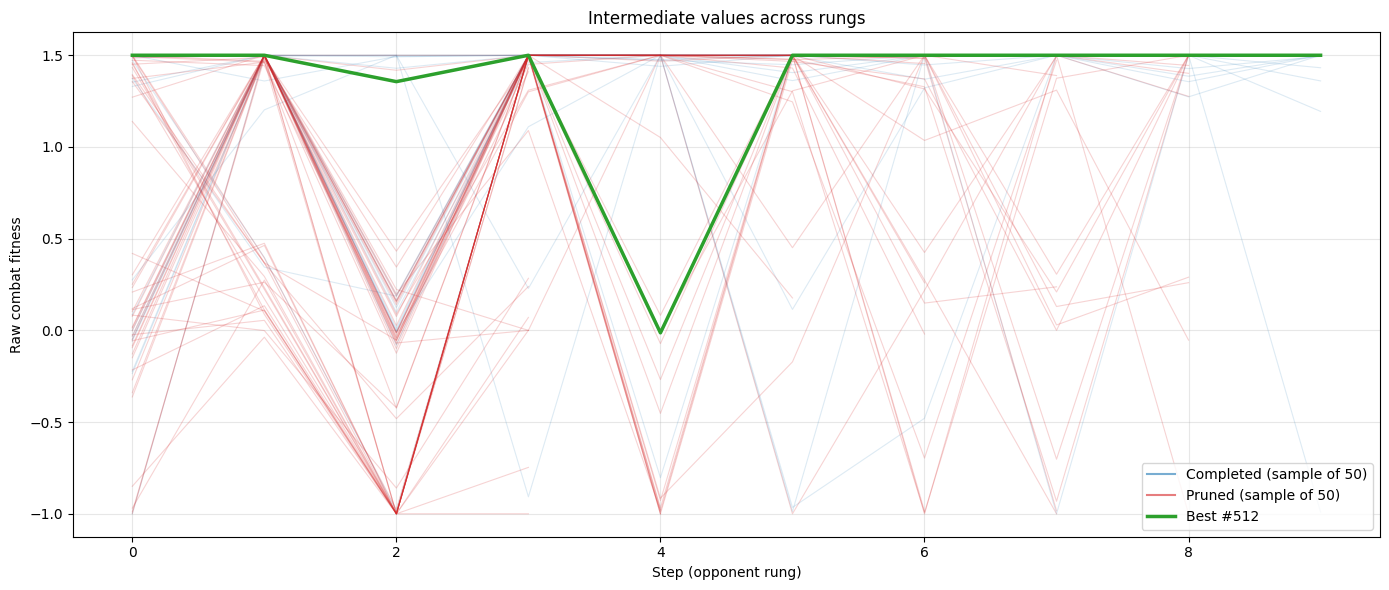

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

def plot_trial(t, color, alpha, linewidth=0.8, label=None):
    if not t.intermediate_values:
        return
    steps = sorted(t.intermediate_values.keys())
    vals = [t.intermediate_values[s] for s in steps]
    ax.plot(steps, vals, color=color, alpha=alpha, linewidth=linewidth, label=label)

rng = np.random.default_rng(0)
sample = 50
completed_sample = rng.choice(completed, size=min(sample, len(completed)), replace=False) if completed else []
pruned_sample = rng.choice(pruned, size=min(sample, len(pruned)), replace=False) if pruned else []

for t in completed_sample:
    plot_trial(t, "tab:blue", 0.15)
for t in pruned_sample:
    plot_trial(t, "tab:red", 0.2)

best = max(completed, key=lambda t: t.value) if completed else None
if best is not None:
    plot_trial(best, "tab:green", 1.0, linewidth=2.5,
               label=f"Best (#{best.number}, f={best.value:.3f})")

# Legend proxies
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color="tab:blue", alpha=0.6, label=f"Completed (sample of {len(completed_sample)})"),
    Line2D([0], [0], color="tab:red", alpha=0.6, label=f"Pruned (sample of {len(pruned_sample)})"),
]
if best is not None:
    handles.append(Line2D([0], [0], color="tab:green", linewidth=2.5,
                          label=f"Best #{best.number}"))
ax.legend(handles=handles)
ax.set_xlabel("Step (opponent rung)")
ax.set_ylabel("Raw combat fitness")
ax.set_title("Intermediate values across rungs")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Throughput Over Time

Cumulative evaluations and per-hour rate from eval log timestamps.

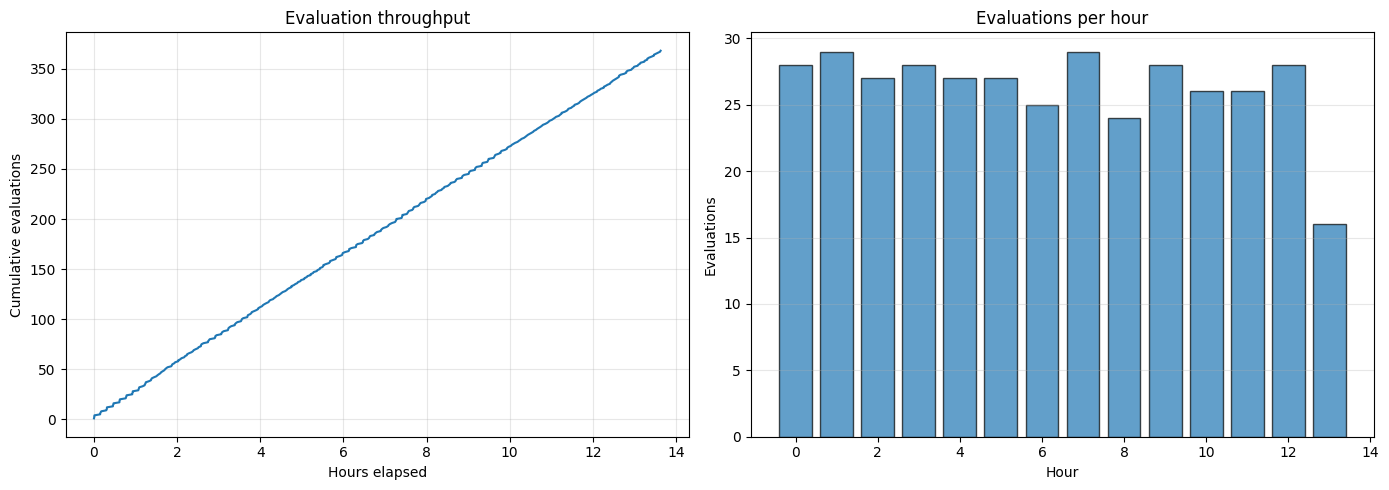

Total runtime so far: 13.6 hours
Average throughput: 27.0 evaluations/hour


In [6]:
from datetime import datetime

timestamps = [datetime.fromisoformat(e["timestamp"]) for e in eval_entries if "timestamp" in e]

if timestamps:
    timestamps_sorted = sorted(timestamps)
    start = timestamps_sorted[0]
    hours = [(t - start).total_seconds() / 3600 for t in timestamps_sorted]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hours, range(1, len(hours) + 1))
    axes[0].set_xlabel("Hours elapsed")
    axes[0].set_ylabel("Cumulative evaluations")
    axes[0].set_title("Evaluation throughput")
    axes[0].grid(True, alpha=0.3)

    hour_bins = [int(h) for h in hours]
    hourly = pd.Series(hour_bins).value_counts().sort_index()
    axes[1].bar(hourly.index, hourly.values, edgecolor="black", alpha=0.7)
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Evaluations")
    axes[1].set_title("Evaluations per hour")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    total_hours = max(hours)
    if total_hours > 0:
        print(f"Total runtime so far: {total_hours:.1f} hours")
        print(f"Average throughput: {len(timestamps) / total_hours:.1f} evaluations/hour")
else:
    print("No timestamps in eval log")

## Combat Duration & Outcome

Per-matchup duration and winner mix across the whole run.

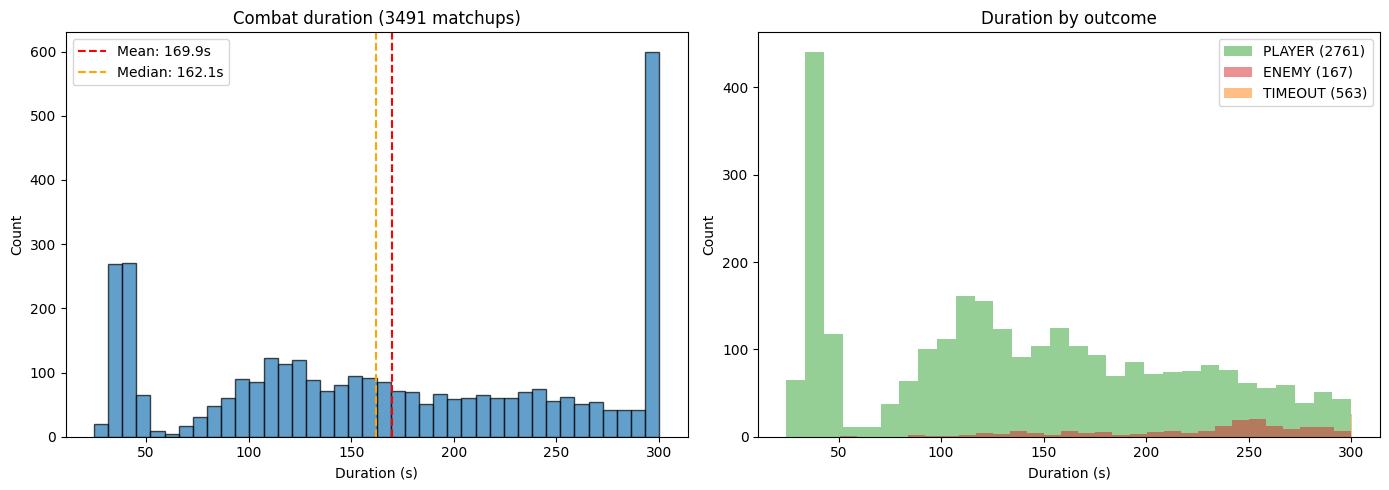

Outcome distribution:
  PLAYER: 2761 (79%)  mean duration=140.1s
  TIMEOUT: 563 (16%)  mean duration=300.1s
  ENEMY: 167 (5%)  mean duration=224.5s


In [7]:
durations = []
outcomes = []
for e in eval_entries:
    for r in e["opponent_results"]:
        durations.append(r["duration_seconds"])
        outcomes.append(r["winner"])

durations = np.array(durations)
outcomes = np.array(outcomes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(durations, bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(durations.mean(), color="red", linestyle="--",
                label=f"Mean: {durations.mean():.1f}s")
axes[0].axvline(np.median(durations), color="orange", linestyle="--",
                label=f"Median: {np.median(durations):.1f}s")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Combat duration ({len(durations)} matchups)")
axes[0].legend()

outcome_colors = {"PLAYER": "tab:green", "ENEMY": "tab:red",
                  "TIMEOUT": "tab:orange", "STOPPED": "tab:gray"}
for outcome in ["PLAYER", "ENEMY", "TIMEOUT", "STOPPED"]:
    mask = outcomes == outcome
    if mask.any():
        axes[1].hist(durations[mask], bins=30, alpha=0.5,
                     label=f"{outcome} ({mask.sum()})",
                     color=outcome_colors.get(outcome))
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Duration by outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Outcome distribution:")
for outcome, count in pd.Series(outcomes).value_counts().items():
    pct = 100 * count / len(outcomes)
    mean_dur = durations[outcomes == outcome].mean()
    print(f"  {outcome}: {count} ({pct:.0f}%)  mean duration={mean_dur:.1f}s")